In [2]:
from scipy import signal
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pylab as plt
import numpy as np
from reservoir_fnn import Reservoir_fnn
import torch
from reservoir_rnn import Reservoir_rnn
import random
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
from joblib import Parallel, delayed
from tqdm import tqdm
import utils

In [4]:
# 参数定义
predict_len=22    # embedding length
train_len=35    # trainning length
D = 150     # embeddings dimension
K = 100      # random select dimension
E = np.load(r'data/E_deep_raw.npy')#(31个测站，3652个时间点)
N = np.load(r'data/N_deep_raw.npy')#(31个测站，3652个时间点)

In [5]:
# 使用的测站
stations = ['THAP','MKNO','OHIN','TAKP','PNUI','NRSW','GRNG','GNBK','MTBL','DNVK']
print(len(stations))

10


In [4]:
# stations = ['PUKE','ANAU','AHTI','CNST','MATW','TKAR','GISB']

In [5]:
model = Reservoir_rnn(1,len(stations),D)

rmse_stations = np.zeros((2, len(stations),  E.shape[1]-train_len-predict_len))
mse_stations = np.zeros((2, len(stations), E.shape[1]-train_len-predict_len))
pcc_stations = np.zeros((2, len(stations), E.shape[1]-train_len-predict_len))
predict_timeseries = np.zeros((2, len(stations), E.shape[1]-train_len-predict_len,predict_len-1))
# for station in range(len(stations)):  # staion y_value
# station=6
def eop_predict(station):

    predict_pred_tt = np.zeros((2, E.shape[1]-train_len+predict_len,predict_len-1))

    for tt in range(E.shape[1]-train_len): #start time  E.shape[1]-train_len-predict_len 3582,
        print(tt)
        xx = np.stack((E[:,tt:], N[:,tt:]), axis=0)                    # 全部序列，xx(2,31,3648)
        traindata = xx[:,:,:train_len]        # 训练序列 traindata(2,31,50)
        real_y = xx[:,station,:]              # real_y(2,3648)
        traindata_y = real_y[:,:train_len]    # traindata_y(50)

        # model.eval()
        with torch.no_grad():
            traindata_x_input_e = torch.from_numpy((traindata[0,:,:].squeeze())[np.newaxis,:,:].astype(np.float32))
            traindata_x_NN_e = np.squeeze(model(traindata_x_input_e).detach().numpy()) # traindata_x_NN(150,50)
            traindata_x_input_n = torch.from_numpy((traindata[1,:,:].squeeze())[np.newaxis,:,:].astype(np.float32))
            traindata_x_NN_n = np.squeeze(model(traindata_x_input_n).detach().numpy()) # traindata_x_NN(150,50)
            traindata_x_NN = np.stack((traindata_x_NN_e, traindata_x_NN_n), axis=0)

        w_flag=np.zeros((np.size(traindata_x_NN,0),np.size(traindata_x_NN,1)))              # 权重更新提示矩阵
        B = np.zeros((np.size(traindata_x_NN,0),np.size(traindata_x_NN,1),predict_len))   # B矩阵
        A = np.zeros((predict_len, np.size(traindata_x_NN,0),np.size(traindata_x_NN,1)))  # A矩阵
        predict_pred=np.zeros((np.size(traindata_x_NN,0),predict_len-1))                  # 每次迭代的预测存储矩阵

        #cal coeffcient matrix B
        iter = 0
        for iter in range(1000):
            random_idx = np.sort(random.sample(range(np.size(traindata_x_NN,1)), k=K))  # 随机索引
            traindata_x=traindata_x_NN[:,random_idx,:]                                    # 随机变量
            for i in range(np.size(traindata_x,1)):         # 遍历每一个变量维度
                b=traindata_x[:, i,:train_len-predict_len+1].T
                a = np.zeros((np.size(b,1),np.size(b,0),predict_len))
                for k in range(np.size(b,1)):
                    for j in range(train_len-predict_len+1):    # 延迟嵌入
                        a[k,j,:]=traindata_y[k,j:j+predict_len]

                    B_para, residuals, rank, s = np.linalg.lstsq(a[k,:,:].squeeze(), b[:,k].squeeze(), rcond=None)
                    # 更新B矩阵
                    B[k,random_idx[i],:]=(B[k,random_idx[i],:]+B_para+B_para*(1-w_flag[k,random_idx[i]]))/2
                    w_flag[k,random_idx[i]]=1

            # tmp predict based on B
            super_AA = np.zeros((np.size(traindata_x_NN,0),np.size(traindata_x_NN,1)*(predict_len-1),predict_len-1))
            super_bb = np.zeros((np.size(traindata_x_NN,0),np.size(traindata_x_NN,1)*(predict_len-1)))
            for i in range(traindata_x_NN.shape[1]):
                kt = 0
                bb = np.zeros((traindata_x_NN.shape[0], predict_len - 1))
                AA = np.zeros((traindata_x_NN.shape[0], predict_len - 1, predict_len - 1))
                for k in range(traindata_x_NN.shape[0]):
                    kt=0
                    for j in range(train_len - (predict_len - 1), train_len):
                        kt += 1
                        bb[k, kt - 1] = traindata_x_NN[k, i, j]

                        col_known_y_num = train_len - j
                        for r in range(col_known_y_num):
                            bb[k, kt - 1] -= B[k, i, r] * traindata_y[k, train_len - col_known_y_num + r]

                        AA[k, kt - 1, :predict_len - col_known_y_num] = B[k, i, col_known_y_num:predict_len]

                    super_bb[k, (predict_len - 1) * i:(predict_len - 1) * i + (predict_len - 1)] = bb[k,:]
                    super_AA[k, (predict_len - 1) * i:(predict_len - 1) * i + (predict_len - 1), :] = AA[k,:,:]

            pred_y_tmp0, residuals, rank, s = np.linalg.lstsq(super_AA[0,:,:].squeeze(), super_bb[0,:].squeeze(), rcond=None)
            pred_y_tmp1, residuals, rank, s = np.linalg.lstsq(super_AA[1,:,:].squeeze(), super_bb[1,:].squeeze(), rcond=None)
            pred_y_tmp = np.stack((pred_y_tmp0, pred_y_tmp1), axis=0)

            # 更新矩阵
            tmp_y = np.concatenate([real_y[:,:train_len], pred_y_tmp], axis=1)  # 连接真实值和预测值
            Ym = np.zeros((tmp_y.shape[0],predict_len, train_len))

            for k in range(tmp_y.shape[0]):
                for j in range(predict_len):
                    Ym[k,j, :] = tmp_y[k,j:j + train_len]

            BX = np.concatenate((B, traindata_x_NN), axis=2)  # 水平拼接 B 和 traindata_x_NN
            IY = np.concatenate([np.array([np.eye(predict_len),np.eye(predict_len)]), Ym], axis=2)  # 拼接单位矩阵和 Ym
            A = IY @ np.linalg.pinv(BX)  # 计算 A

            union_predict_y_ARNN = np.zeros((2,predict_len - 1))  # 初始化预测结果数组
            for j1 in range(predict_len-1):
                tmp_y = np.zeros((2,predict_len - j1-1))
                kt = 0
                for j2 in range(j1, predict_len-1):  # j2 从 j1 到 predict_len - 1
                    row = j2 + 1  # 在 Python 中索引从0开始，因此 j2 + 1 仍然有效
                    col = train_len - j2 + j1 -1  # 计算列索引
                    for k in range(tmp_y.shape[0]):
                        # print(row,col,kt)
                        # print(len(A[k,row, :]))
                        # print(len(traindata_x_NN[k,:, col]))
                        tmp_y[k,kt] = A[k,row, :] @ traindata_x_NN[k,:, col]  # 矩阵乘法计算
                    kt += 1
                union_predict_y_ARNN[:,j1] = np.mean(tmp_y,axis=1)  # 计算均值并存储

            eof_error=np.sqrt(mean_squared_error(union_predict_y_ARNN, predict_pred))
            predict_pred = union_predict_y_ARNN

            iter += 1
            # print(iter)
            # 迭代到收敛
            if eof_error<0.000001:
                break
        for i in range(predict_pred.shape[0]):
            predict_pred_tt[i,tt,:] = predict_pred[i,:]
            # myreal=real_y[i,train_len:train_len+predict_len-1]
            # correlation, p_value = pearsonr(predict_pred[i,:],myreal)
            # pcc_y[i,tt]=correlation
            # rmse=np.sqrt(mean_squared_error(myreal, predict_pred[i,:]))
            # rmse_y[i,tt]=rmse

    return predict_pred_tt


results = Parallel(n_jobs=-1)(delayed(eop_predict)(station) for station in range(len(stations)))

In [6]:
# 将结果提取并合并
predict_timeseries = np.zeros((2, len(stations), E.shape[1] - train_len + predict_len, predict_len - 1))
# pcc_stations = np.zeros((2, len(stations), E.shape[1] - train_len + predict_len))
# rmse_stations = np.zeros((2, len(stations), E.shape[1] - train_len + predict_len))

for idx, (predict_pred_tt) in enumerate(results):
    predict_timeseries[:,idx, :, :] = predict_pred_tt
    # pcc_stations[:,idx, :] = pcc_y
    # rmse_stations[:,idx, :] = rmse_y

np.save('results/deep/pt.npy',predict_timeseries)
# np.save('results/dispne_rnn_50days_raw/ps1.npy',pcc_stations)
# np.save('results/dispne_rnn_50days_raw/rs1.npy',rmse_stations)

In [6]:
import matplotlib.pylab as plt
import numpy as np
import torch
import random
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

predict_timeseries = np.load('results/deep/pt.npy')
# pcc_stations = np.load('results/dispne_rnn_50days_raw/ps1.npy')
# rmse_stations = np.load('results/dispne_rnn_50days_raw/rs1.npy')

In [7]:
station_idx=2
E_array=np.zeros((predict_timeseries[0,station_idx,:,:].shape[0],predict_timeseries[0,station_idx,:,:].shape[0]+predict_len-1))
pts_E_days = np.zeros((predict_timeseries[0,station_idx,:,:].shape[0],predict_timeseries[0,station_idx,:,:].shape[-1]))
for i in range(predict_timeseries[0,station_idx,:,:].shape[0]):
    E_array[i,i:i+predict_len-1] = predict_timeseries[0,station_idx,i,:]
pts_E = np.array([arr[arr != 0].mean() if np.any(arr != 0) else 0 for arr in E_array.T])
pts_E_days = predict_timeseries[0,station_idx,:,:]

N_array=np.zeros((predict_timeseries[1,station_idx,:,:].shape[0],predict_timeseries[1,station_idx,:,:].shape[0]+predict_len-1))
pts_N_days = np.zeros((predict_timeseries[1,station_idx,:,:].shape[0],predict_timeseries[1,station_idx,:,:].shape[-1]))
for i in range(predict_timeseries[1,station_idx,:,:].shape[0]):
    N_array[i,i:i+predict_len-1] = predict_timeseries[1,station_idx,i,:]
pts_N = np.array([arr[arr != 0].mean() if np.any(arr != 0) else 0 for arr in E_array.T])
pts_N_days = predict_timeseries[1,station_idx,:,:]

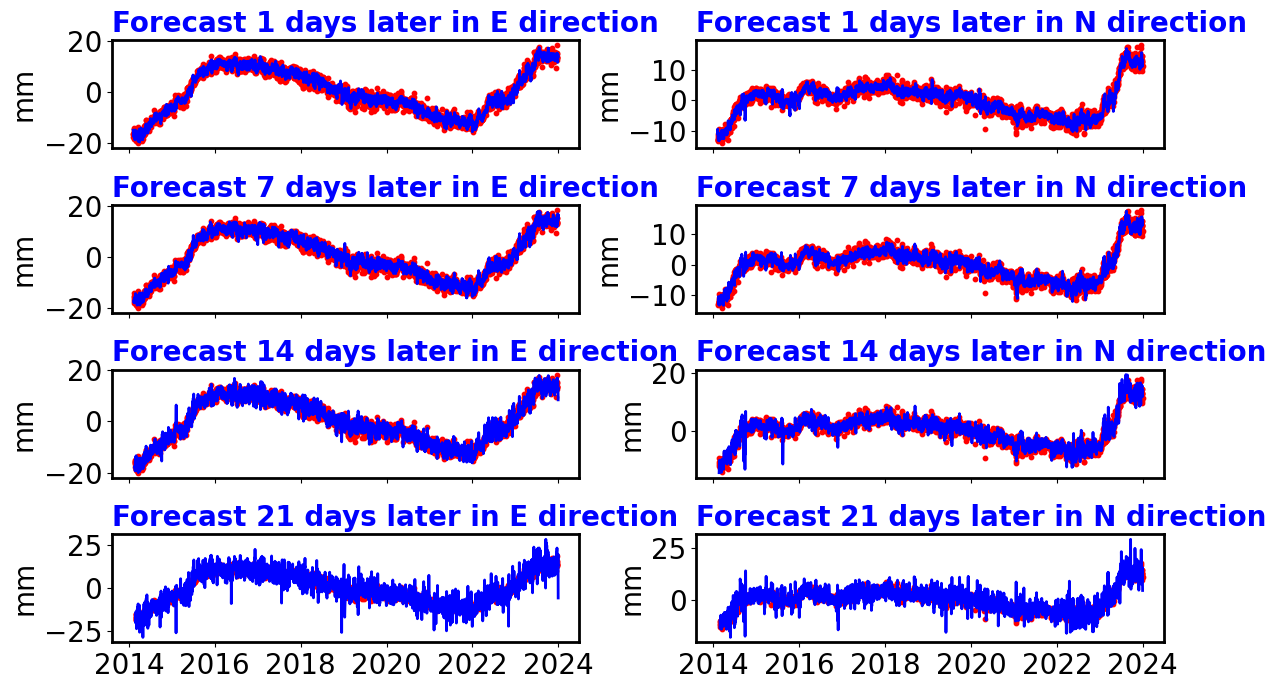

In [8]:
index=[0,6,13,20]
start_date = pd.Timestamp("2014-01-01 11:59:00+00:00")
end_date = pd.Timestamp('2023-12-31 11:59:00+00:00')
dates = pd.date_range(start=start_date, end=end_date, freq='D')
# 创建图形
labelsize=20
fig, axes = plt.subplots(4, 2, figsize=(12, 7), sharex=True)
for i in range(4):
    for j in range(2):
        # 绘制位移 (左 y 轴)
        if j==0:
            axes[i,j].plot(dates[train_len+index[i]:],pts_E_days[index[i]:3652-train_len,index[i]], color='blue', label='Displacement',lw=2)
            axes[i,j].scatter(dates[train_len+index[i]:-7],E[station_idx,train_len+index[i]:-7],c="red",s=10)

            # axes[0].set_ylim(-20,20)
            axes[i,j].tick_params(axis='y',  labelsize=labelsize)
            axes[i,j].set_title("Forecast {} days later in E direction".format(index[i]+1), loc='left', fontsize=labelsize, fontweight='bold', color='blue')
            axes[i,j].tick_params(axis='both', labelsize=labelsize)# 设置刻度大小
            axes[i,j].set_ylabel("mm",fontsize=labelsize)
        if j==1:
            axes[i,j].plot(dates[train_len+index[i]:],pts_N_days[index[i]:3652-train_len,index[i]], color='blue', label='Displacement',lw=2)
            axes[i,j].scatter(dates[train_len+index[i]:],N[station_idx,train_len+index[i]:],c="red",s=10)
            # cal_index(N[station_idx,train_len+index[i]:],pts_N_days[index[i]:3652-train_len,index[i]])
            # axes[0].set_ylim(-20,20)
            axes[i,j].tick_params(axis='y',  labelsize=labelsize)
            axes[i,j].set_title("Forecast {} days later in N direction".format(index[i]+1), loc='left', fontsize=labelsize, fontweight='bold', color='blue')
            axes[i,j].tick_params(axis='both', labelsize=labelsize)# 设置刻度大小
            axes[i,j].set_ylabel("mm",fontsize=labelsize)
# 调整子图间距
# plt.tight_layout()
# plt.show()
import matplotlib.dates as mdates
# x轴每隔5年一个主刻度
locator = mdates.YearLocator(2)
formatter = mdates.DateFormatter('%Y')

for ax in axes.flat:
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

# 如果只想最底下一行显示x轴标签
for ax in axes[:-1, :].flat:
    ax.tick_params(labelbottom=False)

for ax in axes.flat:
    for spine in ax.spines.values():
        spine.set_linewidth(2)
# # # 设置全局X轴
# # axes[-1].set_xlabel('Time [years]', fontsize=20)
#
# 调整子图间距
plt.tight_layout()
# plt.savefig('results/deep/predict.pdf',dpi=300)
# plt.show()


In [38]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def cal_index(y_true, y_pred):
    # 计算 MSE (均方误差)
    mse = mean_squared_error(y_true, y_pred)

    # 计算 MAE (平均绝对误差)
    mae = mean_absolute_error(y_true, y_pred)

    # 计算 RMSE (均方根误差)
    rmse = np.sqrt(mse)

    # 计算 R² (决定系数)
    r2 = r2_score(y_true, y_pred)

    # 计算 MAPE (平均绝对百分比误差)
    errors = y_true- y_pred
    mape = (np.abs(errors /y_true)).mean()

    pcc, p_value = pearsonr(y_true,y_pred)

    # 输出结果
    print(f'MSE: {mse}')
    print(f'MAE: {mae}')
    print(f'RMSE: {rmse}')
    print(f'R²: {r2}')
    print(f'MAPE: {mape}%')
    print(f'皮尔逊相关系数 (PCC): {pcc}')

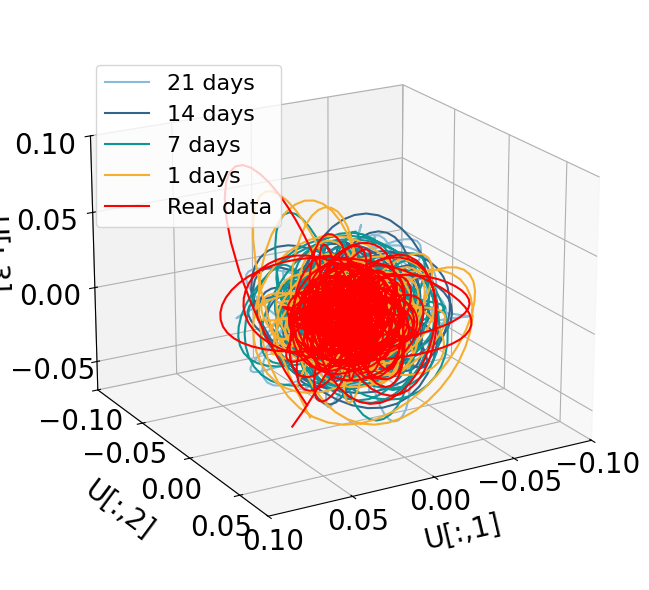

In [19]:
from scipy.signal import firwin, freqz
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import svd

def filter(df):
    #滤波
    L = 40
    fc = 1 / 50
    nyquist = 0.5
    normalized_cutoff = fc / nyquist
    FIR = firwin(L, normalized_cutoff, window='hamming')
    df_filter = np.convolve(df, FIR, mode='same')
    return df_filter
data = np.diff(filter(E[station_idx,train_len:]))

# 延迟嵌入函数
def delay_embedding_and_svd_decomponent(data):
    # 参数设置
    delay = 1  # 延迟
    embedding_dim = 50  # 嵌入向量的维度
    data = np.diff(filter(data))

    n_samples = len(data) - (embedding_dim - 1) * delay
    if n_samples <= 0:
        raise ValueError("输入时间序列长度不足以进行延迟嵌入")

    # 构造嵌入矩阵
    embedded_matrix = np.array([data[i:i + n_samples] for i in range(0, embedding_dim * delay, delay)]).T

    U, S, Vt = svd(embedded_matrix, full_matrices=False)

    return U
size=20
U = delay_embedding_and_svd_decomponent(np.diff(filter(E[station_idx,train_len:])))
# U1 = utils.delay_embedding_and_svd_decomponent(pts_E[:3617])
U_0 = delay_embedding_and_svd_decomponent(np.diff(filter(pts_E_days[:3652-train_len,0])))
U_6 = delay_embedding_and_svd_decomponent(np.diff(filter(pts_E_days[:3652-train_len,6])))
U_13 = delay_embedding_and_svd_decomponent(np.diff(filter(pts_E_days[:3652-train_len,13])))
U_20 = delay_embedding_and_svd_decomponent(np.diff(filter(pts_E_days[:3652-train_len,20])))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel("U[:,1]",fontsize=size,labelpad=9)
ax.set_ylabel("U[:,2]",fontsize=size,labelpad=18)
ax.set_zlabel("U[:,3]",fontsize=size,labelpad=24)

# 绘制轨迹
ax.plot(U_20[:,0], U_20[:,1], U_20[:,2], color='#87BBD8', linewidth=1.5,label='21 days')
ax.plot(U_13[:,0], U_13[:,1], U_13[:,2], color='#33658B', linewidth=1.5,label='14 days')
ax.plot(U_6[:,0], U_6[:,1], U_6[:,2], color='#0D9695', linewidth=1.5,label='7 days')
ax.plot(U_0[:,0], U_0[:,1], U_0[:,2], color='#F6AE2E', linewidth=1.5,label='1 days')
ax.plot(U[:,0],U[:,1],  U[:,2], color='red', linewidth=1.5,label='Real data')
# ax.plot(U1[:,0], U1[:,1], U1[:,2], color='yellow', linewidth=1.5)

# 设置刻度为整 0.05 倍数
x_ticks = [-0.1,-0.05,0,0.05,0.1]#np.arange(np.ceil(U[:, 0].min() * 20) / 20, np.floor(U[:, 0].max() * 20) / 20 , 0.05)
y_ticks = [-0.1,-0.05,0,0.05]#np.arange(np.ceil(U[:, 1].min() * 20) / 20, np.floor(U[:, 1].max() * 20) / 20 , 0.05)
z_ticks = [-0.05,0,0.05,0.1]#np.arange(np.ceil(U[:, 2].min() * 20) / 20, np.floor(U[:, 2].max() * 20) / 20 , 0.05)

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_zticks(z_ticks)
ax.tick_params(axis='x', labelsize=size, pad=-2)
ax.tick_params(axis='y', labelsize=size, pad=4)
ax.tick_params(axis='z', labelsize=size, pad=12)

ax.legend(bbox_to_anchor=(0.43, 0.6),fontsize=16)
ax.view_init(elev=20,azim=60)

plt.tight_layout()
plt.savefig('results/deep/attract_E.pdf')
plt.show()

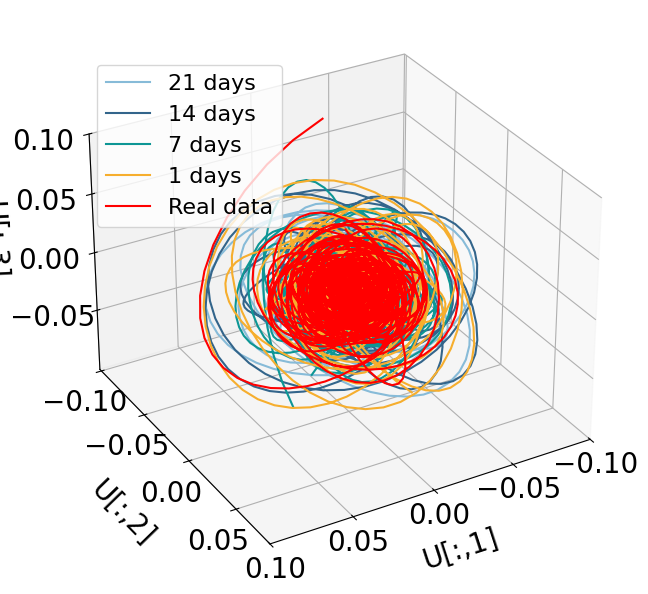

In [18]:
size=20
U_N = delay_embedding_and_svd_decomponent(np.diff(filter(N[station_idx,train_len:])))
# U1 = utils.delay_embedding_and_svd_decomponent(pts_E[:3617])
U_0_N = delay_embedding_and_svd_decomponent(np.diff(filter(pts_N_days[:3652-train_len,0])))
U_6_N = delay_embedding_and_svd_decomponent(np.diff(filter(pts_N_days[:3652-train_len,6])))
U_13_N = delay_embedding_and_svd_decomponent(np.diff(filter(pts_N_days[:3652-train_len,13])))
U_20_N = delay_embedding_and_svd_decomponent(np.diff(filter(pts_N_days[:3652-train_len,20])))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel("U[:,1]",fontsize=size,labelpad=9)
ax.set_ylabel("U[:,2]",fontsize=size,labelpad=18)
ax.set_zlabel("U[:,3]",fontsize=size,labelpad=24)

# 绘制轨迹
ax.plot(U_20_N[:,0], U_20_N[:,1], U_20_N[:,2], color='#87BBD8', linewidth=1.5,label='21 days')
ax.plot(U_13_N[:,0], U_13_N[:,1], U_13_N[:,2], color='#33658B', linewidth=1.5,label='14 days')
ax.plot(U_6_N[:,0], U_6_N[:,1], U_6_N[:,2], color='#0D9695', linewidth=1.5,label='7 days')
ax.plot(U_0_N[:,0], U_0_N[:,1], U_0_N[:,2], color='#F6AE2E', linewidth=1.5,label='1 days')
ax.plot(U_N[:,1],U_N[:,0],  -U_N[:,2], color='red', linewidth=1.5,label='Real data')
# ax.plot(U1[:,0], U1[:,1], U1[:,2], color='yellow', linewidth=1.5)

# 设置刻度为整 0.05 倍数
x_ticks = [-0.1,-0.05,0,0.05,0.1]
y_ticks = [-0.1,-0.05,0,0.05]
z_ticks = np.arange(np.ceil(U[:, 2].min() * 20) / 20, np.ceil(U[:, 2].max() * 20) / 20 , 0.05)

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_zticks(z_ticks)
ax.tick_params(axis='x', labelsize=size, pad=-2)
ax.tick_params(axis='y', labelsize=size, pad=4)
ax.tick_params(axis='z', labelsize=size, pad=12)

ax.legend(bbox_to_anchor=(0.43, 0.6),fontsize=16)
ax.view_init(elev=30,azim=60)
plt.tight_layout()
plt.savefig('results/deep/attract_N.pdf')
plt.show()

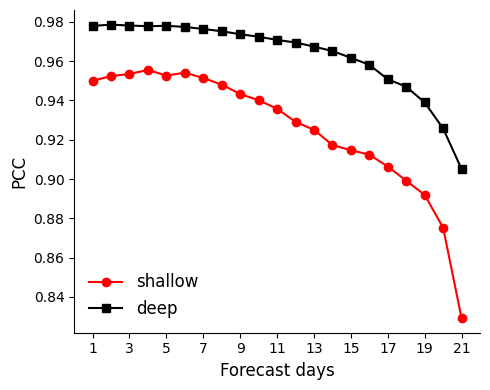

In [16]:
from scipy.stats import pearsonr
pcc_array = []
for i in range(21):
    corr, _ = pearsonr(E[station_idx,train_len+i:], pts_E_days[i:3652-train_len,i])
    pcc_array.append(corr)
# plt.plot(pcc_array)
pcc_deep  = pcc_array
pcc_shallow = np.load('results/shallow/pcc.npy')

plt.figure(figsize=(5,4))
plt.plot(range(1,22),pcc_shallow,label='shallow',marker='o', linestyle='-', markersize=6,color='red')
plt.plot(range(1,22),pcc_deep,label='deep',marker='s', linestyle='-', markersize=6,color='black')
plt.xlabel('Forecast days',fontsize=12)
plt.ylabel('PCC',fontsize=12)

# 设置图形的顶部和右边的边框消失
ax = plt.gca()  # 获取当前的坐标轴
ax.spines['top'].set_visible(False)  # 去掉顶部边框
ax.spines['right'].set_visible(False)  # 去掉右边边框
plt.xticks([1,3,5,7,9,11,13,15,17,19,21])
plt.legend(frameon=False,fontsize=12)
# plt.show
plt.tight_layout()
plt.savefig('results/deep/pcc.pdf',dpi=600)

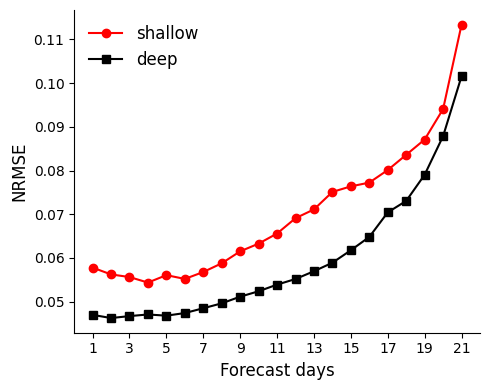

In [17]:
from scipy.stats import pearsonr
NRMSE_array = []
for i in range(21):
    y = E[station_idx,train_len+i:]
    y_hat = pts_E_days[i:3652-train_len,i]
    NRMSE = np.sqrt(np.mean((y - y_hat)**2)) / (np.max(y) - np.min(y))
    NRMSE_array.append(NRMSE)
# plt.plot(pcc_array)
NRMSE_deep  = NRMSE_array
NRMSE_shallow = np.load('results/shallow/NRMSE.npy')

plt.figure(figsize=(5,4))
plt.plot(range(1,22),NRMSE_shallow,label='shallow',marker='o', linestyle='-', markersize=6,color='red')
plt.plot(range(1,22),NRMSE_deep,label='deep',marker='s', linestyle='-', markersize=6,color='black')
plt.xlabel('Forecast days',fontsize=12)
plt.ylabel('NRMSE',fontsize=12)
# 设置图形的顶部和右边的边框消失
ax = plt.gca()  # 获取当前的坐标轴
ax.spines['top'].set_visible(False)  # 去掉顶部边框
ax.spines['right'].set_visible(False)  # 去掉右边边框
plt.xticks([1,3,5,7,9,11,13,15,17,19,21])
plt.legend(frameon=False,fontsize=12)
# plt.show
plt.tight_layout()
plt.savefig('results/deep/nrmse.pdf',dpi=600)

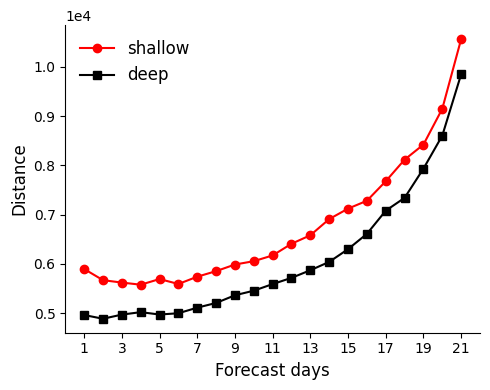

In [18]:
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
import matplotlib.ticker as ticker
distance_array = []
for i in range(21):
    X = E[station_idx,train_len+i:]
    Y = pts_E_days[i:3652-train_len,i]
        # 将时间序列转换为 (x, y) 点的形式
    X_points = [(i, X[i]) for i in range(len(X))]
    Y_points = [(i, Y[i]) for i in range(len(Y))]

    # 计算DTW距离
    distance, path = fastdtw(X_points, Y_points, dist=euclidean)
    distance_array.append(distance)
# plt.plot(pcc_array)
distance_deep  = distance_array
distance_shallow = np.load('results/shallow/distance.npy')

plt.figure(figsize=(5,4))
plt.plot(range(1,22),distance_shallow,label='shallow',marker='o', linestyle='-', markersize=6,color='red')
plt.plot(range(1,22),distance_deep,label='deep',marker='s', linestyle='-', markersize=6,color='black')
plt.xlabel('Forecast days',fontsize=12)
plt.ylabel('Distance',fontsize=12)
# 设置图形的顶部和右边的边框消失
ax = plt.gca()  # 获取当前的坐标轴
ax.spines['top'].set_visible(False)  # 去掉顶部边框
ax.spines['right'].set_visible(False)  # 去掉右边边框
plt.xticks([1,3,5,7,9,11,13,15,17,19,21])
# 设置科学计数法显示y轴刻度
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend(frameon=False,fontsize=12)
# plt.show
plt.tight_layout()
plt.savefig('results/deep/distance.pdf',dpi=600)